In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA RTX 2000 Ada Generation


In [2]:
#setting the path
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "plantvillage dataset"
IMAGE_SET = DATA_ROOT / "color"
from src.preprocess import scan_images, assign_duplicate_groups, grouped_stratified_split, training_rgb_stats, make_eda_plots


print("Project root:", PROJECT_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Using image set:", IMAGE_SET)
print("Classes:", len([p for p in IMAGE_SET.iterdir() if p.is_dir()]))

Project root: c:\Users\KBE\Desktop\plant-disease-project
Data root exists: True
Using image set: c:\Users\KBE\Desktop\plant-disease-project\data\plantvillage dataset\color
Classes: 38


In [3]:
import pandas as pd

class_dirs = sorted([p for p in IMAGE_SET.iterdir() if p.is_dir()])

rows = []
for class_dir in class_dirs:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        for fp in class_dir.glob(ext):
            rows.append({
                "filepath": str(fp),
                "class_name": class_dir.name
            })

df = pd.DataFrame(rows)
class_to_idx = {name: i for i, name in enumerate(sorted(df["class_name"].unique()))}
df["label"] = df["class_name"].map(class_to_idx)
df["image_id"] = df["filepath"].map(lambda x: Path(x).stem)

# Best case: replace this with real leaf/group metadata
# Temporary fallback only if you do not yet have true group ids
df["group_id"] = df["image_id"]

display(df.head())
print(df.columns.tolist())

print("Total images:", len(df))
print("Total classes:", df["class_name"].nunique())
display(df.head())
display(df["class_name"].value_counts().head(10))

,filepath,class_name,label,image_id,group_id
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...


['filepath', 'class_name', 'label', 'image_id', 'group_id']
Total images: 54305
Total classes: 38


,filepath,class_name,label,image_id,group_id
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...


class_name
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight                             1909
Squash___Powdery_mildew                          1835
Tomato___Septoria_leaf_spot                      1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

group_df = df[["group_id", "label"]].drop_duplicates()

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    stratify=group_df["label"],
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["label"],
    random_state=42
)

train_df = df[df["group_id"].isin(train_groups["group_id"])].reset_index(drop=True)
val_df   = df[df["group_id"].isin(val_groups["group_id"])].reset_index(drop=True)
test_df  = df[df["group_id"].isin(test_groups["group_id"])].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 38013
Val: 8146
Test: 8146


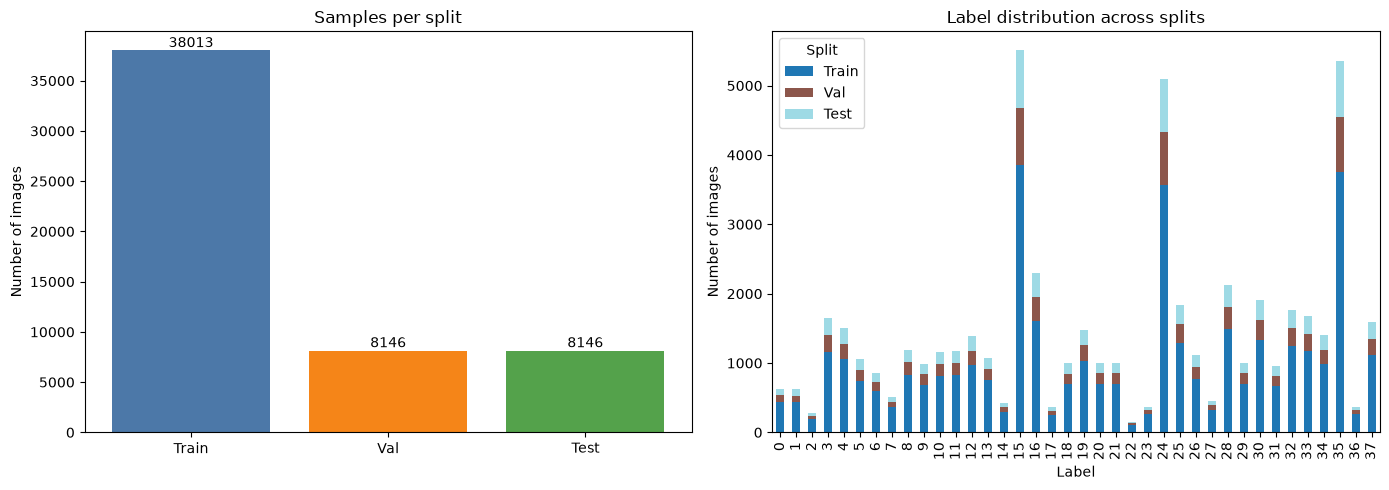

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Split sizes
split_sizes = {
    "Train": len(train_df),
    "Val": len(val_df),
    "Test": len(test_df)
}
axes[0].bar(split_sizes.keys(), split_sizes.values(), color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Samples per split")
axes[0].set_ylabel("Number of images")

for i, v in enumerate(split_sizes.values()):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# 2) Label distribution per split
dist_df = pd.DataFrame({
    "Train": train_df["label"].value_counts().sort_index(),
    "Val": val_df["label"].value_counts().sort_index(),
    "Test": test_df["label"].value_counts().sort_index()
}).fillna(0)

dist_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Label distribution across splits")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Number of images")
axes[1].legend(title="Split")

plt.tight_layout()
plt.show()

In [6]:
print("train-val overlap:", len(set(train_df.group_id) & set(val_df.group_id)))
print("train-test overlap:", len(set(train_df.group_id) & set(test_df.group_id)))
print("val-test overlap:", len(set(val_df.group_id) & set(test_df.group_id)))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [7]:
import torch
from tqdm.auto import tqdm
from torchvision import transforms
from PIL import Image

paths = train_df["filepath"].tolist()


channel_sum = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
pixel_count = 0

for path in tqdm(paths, desc="Computing train mean/std"):
    img = Image.open(path).convert("RGB")
    x = transforms.ToTensor()(img)

    channel_sum += x.sum(dim=(1, 2))
    channel_sum_sq += (x ** 2).sum(dim=(1, 2))
    pixel_count += x.shape[1] * x.shape[2]

mean = channel_sum / pixel_count
std = ((channel_sum_sq / pixel_count) - (mean ** 2)).sqrt()

train_mean = mean.tolist()
train_std = std.tolist()

print("train_mean =", train_mean)
print("train_std  =", train_std)


Computing train mean/std:   0%|          | 0/38013 [00:00<?, ?it/s]

train_mean = [0.4666469991207123, 0.48924359679222107, 0.4107652008533478]
train_std  = [0.19919739663600922, 0.17490631341934204, 0.21735328435897827]


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

In [9]:
#Basic data augmentation for training images
basic_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# Field orientied augmentation for training images
field_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, fill=tuple(int(m * 255) for m in train_mean)),
    transforms.ColorJitter( brightness=0.25, contrast=0.20, saturation=0.15, hue=0.02),
    transforms.RandomApply([transforms.GaussianBlur( kernel_size=5, sigma=(0.1, 1.5))], p=0.20),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.01, 0.06), ratio=(0.5, 2.0), value="random"),
    transforms.Normalize( mean=train_mean,std=train_std )
])

#validation and test processing transform (no augmentation, just resizing and normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

print("Basic training transform created.")
print("Field-oriented training transform created.")
print("Evaluation transform created.")

Basic training transform created.
Field-oriented training transform created.
Evaluation transform created.


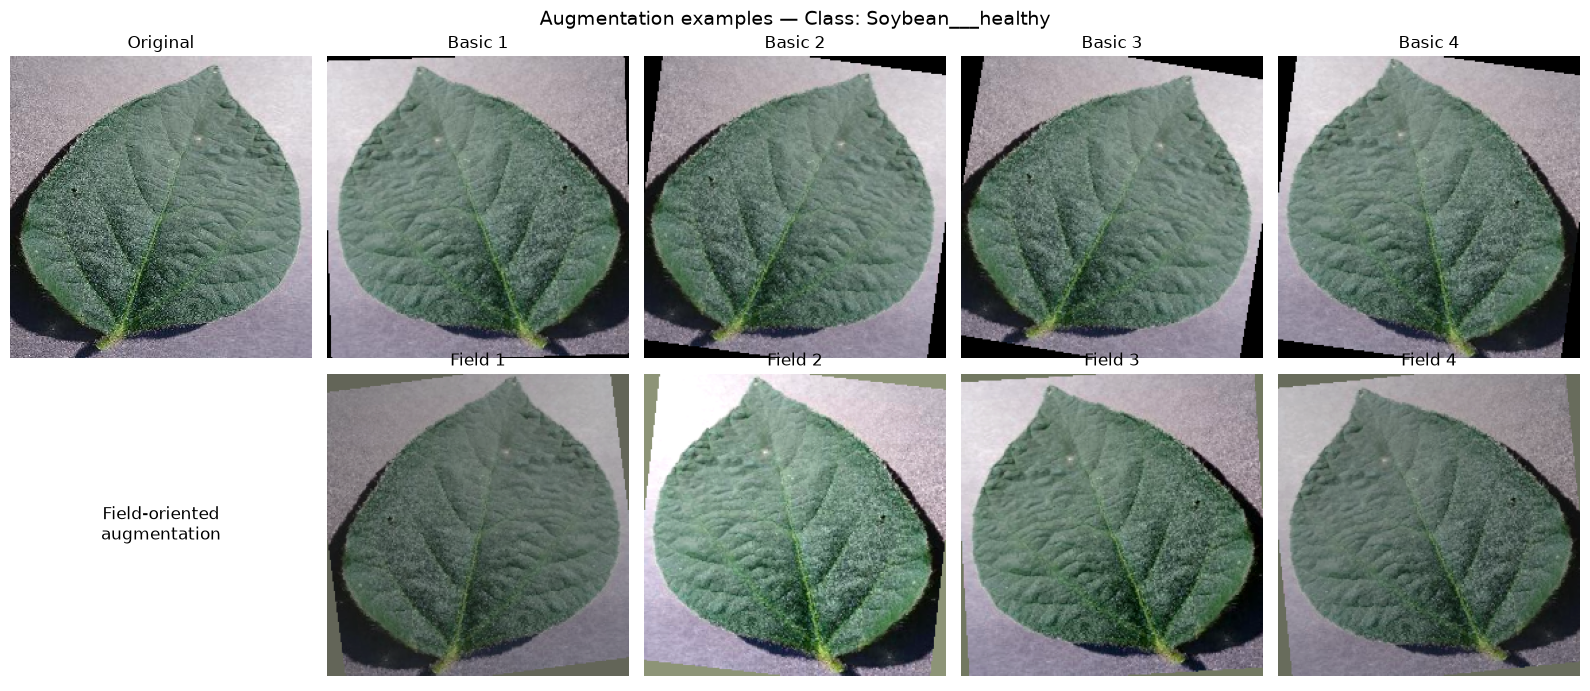

Sample image: c:\Users\KBE\Desktop\plant-disease-project\data\plantvillage dataset\color\Soybean___healthy\1be1388c-544a-48a1-8c85-24a56e5b0b4c___RS_HL 5559.JPG
Class: Soybean___healthy


In [10]:
#Visualise augmented samples
def denormalize_image(image_tensor, mean, std):
    image_tensor = image_tensor.clone()
    mean_tensor = torch.tensor(mean, dtype=image_tensor.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image_tensor.dtype).view(3, 1, 1)
    image_tensor = image_tensor * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1)

def tensor_to_display_image(image_tensor):
    image_tensor = denormalize_image( image_tensor, train_mean, train_std)
    return image_tensor.permute(1, 2, 0).numpy()

# Select a sample image from the training dataframe.
sample_row = train_df.sample( n=1, random_state=42).iloc[0]
sample_path = sample_row["filepath"]
sample_class = sample_row["class_name"]

# Open the original image.
with Image.open(sample_path) as image:
    original_image = image.convert("RGB")

# Create a figure with:
# Row 1: Original image and basic augmentations
# Row 2: Field-oriented augmentations
fig, axes = plt.subplots( nrows=2, ncols=5, figsize=(16, 7))

# Display the original image.
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Display four basic augmented versions.
for column in range(1, 5):
    augmented_tensor = basic_train_transform(original_image)
    display_image = tensor_to_display_image(augmented_tensor)
    axes[0, column].imshow(display_image)
    axes[0, column].set_title(f"Basic {column}")
    axes[0, column].axis("off")

# The first space in the second row is used as a label.
axes[1, 0].text( 0.5, 0.5, "Field-oriented\naugmentation", horizontalalignment="center", verticalalignment="center", fontsize=12)
axes[1, 0].axis("off")

# Display four field-oriented augmented versions.
for column in range(1, 5):
    augmented_tensor = field_train_transform(original_image)
    display_image = tensor_to_display_image(augmented_tensor)
    axes[1, column].imshow(display_image)
    axes[1, column].set_title(f"Field {column}")
    axes[1, column].axis("off")

plt.suptitle(f"Augmentation examples — Class: {sample_class}", fontsize=14)
plt.tight_layout()
plt.show()
print("Sample image:", sample_path)
print("Class:", sample_class)

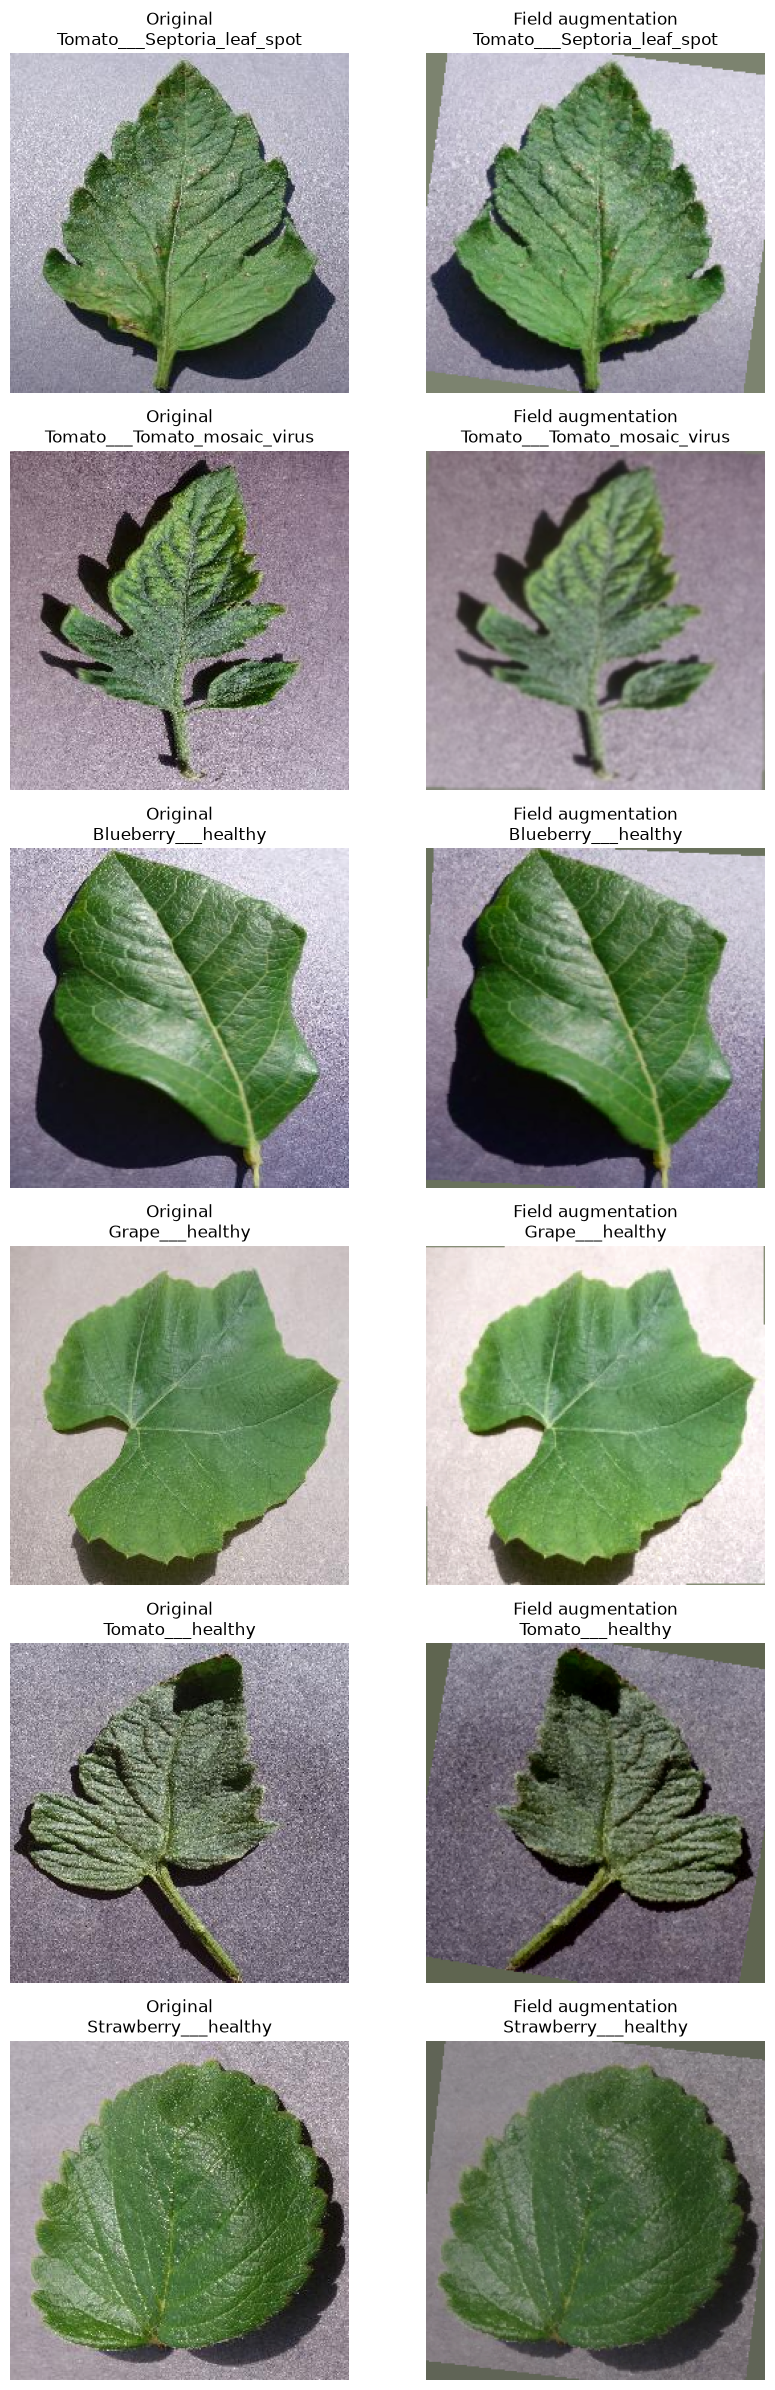

In [11]:
# Select six different classes.
selected_classes = (train_df["class_name"].drop_duplicates().sample(n=min(6, train_df["class_name"].nunique()),random_state=42).tolist())

fig, axes = plt.subplots( nrows=len(selected_classes), ncols=2, figsize=(9, 4 * len(selected_classes)))

# Handle the case where only one class is selected.
if len(selected_classes) == 1:
    axes = [axes]

for row_index, class_name in enumerate(selected_classes):
    # Select one image from the current class.
    class_sample = train_df[train_df["class_name"] == class_name].sample(n=1,random_state=42).iloc[0]
    image_path = class_sample["filepath"]
    with Image.open(image_path) as image:
        original = image.convert("RGB")

    # Create one field-oriented augmented version.
    augmented_tensor = field_train_transform(original)
    augmented = tensor_to_display_image(augmented_tensor)

    # Original image.
    axes[row_index][0].imshow(original)
    axes[row_index][0].set_title(f"Original\n{class_name}")
    axes[row_index][0].axis("off")

    # Augmented image.
    axes[row_index][1].imshow(augmented)
    axes[row_index][1].set_title(f"Field augmentation\n{class_name}")
    axes[row_index][1].axis("off")

plt.tight_layout()
plt.show()

fit preprocessing on training data only

The RGB mean/std and class weights are fitted only on the 68% training split. Validation and test images remain unseen until evaluation.

In [20]:
from pathlib import Path
import json, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from PIL import Image


# Works whether Jupyter was launched from the project root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'src' / 'preprocess.py').exists(), f'Cannot find src/preprocess.py below {PROJECT_ROOT}'
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import scan_images, assign_duplicate_groups, grouped_stratified_split, training_rgb_stats, make_eda_plots

DATA_DIR = PROJECT_ROOT / 'data/plantvillage dataset/color'
OUTPUT_DIR = PROJECT_ROOT / 'artifacts/week2_raw_data'
IMAGE_SIZE = 256  # Change to 512 if that is your final model input
SEED = 42
random.seed(SEED); np.random.seed(SEED)
assert DATA_DIR.exists(), f'Cannot find: {DATA_DIR.resolve()}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_DIR.resolve())



C:\Users\KBE\Desktop\plant-disease-project\data\plantvillage dataset\color


In [ ]:
"""The script does not modify source images. It writes manifests, grouped splits,
EDA figures, and training-only statistics to the requested output directory.
"""
from __future__ import annotations

import argparse
import json
import random
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def scan_images(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Read metadata and a pHash for every valid image; retain errors separately."""
    images = [p for p in data_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    rows, errors = [], []
    for path in tqdm(images, desc="Inspecting images"):
        try:
            with Image.open(path) as img:
                rgb = img.convert("RGB")
                width, height = rgb.size
                # pHash supports exact and visually-near duplicate investigations.
                phash = str(imagehash.phash(rgb))
                # Border colour variance quantifies PlantVillage's uniform backdrop.
                small = np.asarray(rgb.resize((64, 64)), dtype=np.float32)
                border = np.concatenate((small[:6].reshape(-1, 3), small[-6:].reshape(-1, 3), small[:, :6].reshape(-1, 3), small[:, -6:].reshape(-1, 3)))
            rows.append({"path": str(path.resolve()), "label": path.parent.name, "width": width, "height": height, "aspect_ratio": round(width / height, 5), "phash": phash, "border_rgb_variance": round(float(border.var(axis=0).mean()), 4)})
        except Exception as exc:  # Keep corrupt files visible instead of silently dropping them.
            errors.append({"path": str(path.resolve()), "error": str(exc)})
    frame = pd.DataFrame(rows).sort_values(["label", "path"]).reset_index(drop=True)
    if frame.empty:
        raise FileNotFoundError(f"No supported image files found under {data_dir}")
    return frame, pd.DataFrame(errors)


def assign_duplicate_groups(frame: pd.DataFrame) -> pd.DataFrame:
    """Assign exact pHash groups so duplicate images cannot cross split boundaries."""
    result = frame.copy()
    result["duplicate_group"] = result.groupby("phash").ngroup().astype(str)
    conflicts = result.groupby("duplicate_group").label.nunique()
    bad = set(conflicts[conflicts > 1].index)
    if bad:
        raise ValueError(f"{len(bad)} duplicate groups contain conflicting folder labels; resolve these before splitting.")
    return result


def grouped_stratified_split(frame: pd.DataFrame, seed: int, test_size: float, validation_from_train: float) -> pd.DataFrame:
    """Split unique duplicate groups, then map the train/val/test label back to images."""
    units = frame.groupby("duplicate_group", as_index=False).agg(label=("label", "first"))
    train_units, test_units = train_test_split(units, test_size=test_size, random_state=seed, stratify=units.label)
    train_units, val_units = train_test_split(train_units, test_size=validation_from_train, random_state=seed, stratify=train_units.label)
    lookup = pd.concat([train_units.assign(split="train"), 
                        val_units.assign(split="val"), 
                        test_units.assign(split="test")])[["duplicate_group", "split"]]
    return frame.merge(lookup, on="duplicate_group", validate="many_to_one").sort_values(["split", "label", "path"]).reset_index(drop=True)


def training_rgb_stats(train: pd.DataFrame, image_size: int) -> dict:
    """Calculate RGB mean/std after resizing, from training images only."""
    pixel_sum = np.zeros(3, dtype=np.float64); square_sum = np.zeros(3, dtype=np.float64); pixels = 0
    for path in tqdm(train.path, desc="Computing train RGB statistics"):
        with Image.open(path) as img:
            array = np.asarray(img.convert("RGB").resize((image_size, image_size)), dtype=np.float64) / 255.0
        pixel_sum += array.sum(axis=(0, 1)); square_sum += np.square(array).sum(axis=(0, 1)); pixels += image_size * image_size
    mean = pixel_sum / pixels; std = np.sqrt(np.maximum(square_sum / pixels - np.square(mean), 0))
    return {"image_size": image_size, "normalization_mean": mean.round(6).tolist(), "normalization_std": std.round(6).tolist(), "computed_from": "train split only"}


def make_eda_plots(frame: pd.DataFrame, output: Path) -> None:
    output.mkdir(parents=True, exist_ok=True)
    counts = frame.label.value_counts().sort_values(ascending=False)
    pd.DataFrame({"label": counts.index, "count": counts.values}).to_csv(output / "class_counts.csv", index=False)
    plt.figure(figsize=(12, 9)); sns.barplot(x=counts.values, y=counts.index, color="#2878B5"); plt.title("Images per disease class"); plt.xlabel("Images"); plt.ylabel(""); plt.tight_layout(); plt.savefig(output / "class_distribution.png", dpi=180); plt.close()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(frame.width, bins=30, color="#2878B5"); axes[0].set(title="Image widths", xlabel="Pixels")
    axes[1].hist(frame.height, bins=30, color="#2A9D8F"); axes[1].set(title="Image heights", xlabel="Pixels")
    axes[2].hist(frame.aspect_ratio, bins=30, color="#E76F51"); axes[2].set(title="Aspect ratios", xlabel="Width / height")
    fig.tight_layout(); fig.savefig(output / "image_dimensions.png", dpi=180); plt.close(fig)
    plt.figure(figsize=(10, 5)); sns.boxplot(data=frame, x="border_rgb_variance", y="label", color="#8AB17D"); plt.title("Border RGB variance by class (background uniformity)"); plt.xlabel("Mean RGB variance at image border"); plt.ylabel(""); plt.tight_layout(); plt.savefig(output / "background_variance.png", dpi=180); plt.close()


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] --data-plantvillage dataset
                             DATA_PLANTVILLAGE DATASET
                             [--output-dir OUTPUT_DIR]
                             [--image-size IMAGE_SIZE] [--test-size TEST_SIZE]
                             [--validation-from-train VALIDATION_FROM_TRAIN]
                             [--seed SEED]
ipykernel_launcher.py: error: the following arguments are required: --data-plantvillage dataset


SystemExit: 2

In [1]:
raw, unreadable = scan_images(DATA_DIR)
print(f'Images found: {len(raw):,}')
print(f'Classes found: {raw.label.nunique()}')
print(f'Unreadable files: {len(unreadable)}')
assert raw.label.nunique() == 38, 'Expected exactly 38 class folders.'
raw[['label', 'width', 'height', 'aspect_ratio', 'border_rgb_variance']].head()

NameError: name 'scan_images' is not defined

In [28]:
frame = assign_duplicate_groups(raw)

# Intentionally unsafe random image split, used only to audit leakage risk.
random_train, random_test = train_test_split(
    frame.index, test_size=0.20, random_state=SEED, stratify=frame.label
)
random_side = pd.Series('train', index=frame.index)
random_side.loc[random_test] = 'test'
random_crossing = (frame.assign(side=random_side).groupby('duplicate_group').side.nunique() > 1).sum()

# Correct grouped + stratified 68/12/20 split.
splits = grouped_stratified_split(frame, seed=SEED, test_size=0.20, validation_from_train=0.15)
grouped_crossing = (splits.groupby('duplicate_group').split.nunique() > 1).sum()
duplicate_rows = frame[frame.duplicated('duplicate_group', keep=False)].sort_values('duplicate_group')

print(f'Images in exact pHash duplicate groups: {len(duplicate_rows):,}')
print(f'Duplicate groups crossing a random train/test split: {random_crossing:,}')
print(f'Duplicate groups crossing the grouped split: {grouped_crossing:,} (must be 0)')

plt.figure(figsize=(6,4))
bars = plt.bar(['Random split\n(unsafe)', 'Grouped split\n(project split)'], [random_crossing, grouped_crossing], color=['#d9534f', '#5cb85c'])
plt.ylabel('Duplicate groups crossing a split')
plt.title('Perceptual-hash leakage audit on raw PlantVillage images')
for bar, value in zip(bars, [random_crossing, grouped_crossing]):
    plt.text(bar.get_x()+bar.get_width()/2, value, str(value), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

display(pd.crosstab(splits.label, splits.split))

NameError: name 'raw' is not defined

In [22]:
frame = assign_duplicate_groups(raw)

# Intentionally unsafe random image split, used only to audit leakage risk.
random_train, random_test = train_test_split(
    frame.index, test_size=0.20, random_state=SEED, stratify=frame.label
)
random_side = pd.Series('train', index=frame.index)
random_side.loc[random_test] = 'test'
random_crossing = (frame.assign(side=random_side).groupby('duplicate_group').side.nunique() > 1).sum()

# Correct grouped + stratified 68/12/20 split.
splits = grouped_stratified_split(frame, seed=SEED, test_size=0.20, validation_from_train=0.15)
grouped_crossing = (splits.groupby('duplicate_group').split.nunique() > 1).sum()
duplicate_rows = frame[frame.duplicated('duplicate_group', keep=False)].sort_values('duplicate_group')

print(f'Images in exact pHash duplicate groups: {len(duplicate_rows):,}')
print(f'Duplicate groups crossing a random train/test split: {random_crossing:,}')
print(f'Duplicate groups crossing the grouped split: {grouped_crossing:,} (must be 0)')

plt.figure(figsize=(6,4))
bars = plt.bar(['Random split\n(unsafe)', 'Grouped split\n(project split)'], [random_crossing, grouped_crossing], color=['#d9534f', '#5cb85c'])
plt.ylabel('Duplicate groups crossing a split')
plt.title('Perceptual-hash leakage audit on raw PlantVillage images')
for bar, value in zip(bars, [random_crossing, grouped_crossing]):
    plt.text(bar.get_x()+bar.get_width()/2, value, str(value), ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

display(pd.crosstab(splits.label, splits.split))

NameError: name 'raw' is not defined

In [21]:
train = splits.query("split == 'train'").copy()
stats = training_rgb_stats(train, IMAGE_SIZE)
train_counts = train.label.value_counts().sort_index()
class_weights = train_counts.sum() / (len(train_counts) * train_counts)

print(f'Training-only RGB mean for {IMAGE_SIZE}x{IMAGE_SIZE}: {stats["normalization_mean"]}')
print(f'Training-only RGB std  for {IMAGE_SIZE}x{IMAGE_SIZE}: {stats["normalization_std"]}')
display(pd.DataFrame({'train_images': train_counts, 'class_weight': class_weights.round(4)}))

NameError: name 'splits' is not defined